# Fall Detection — pipeline đã tối ưu

Notebook này sửa các lỗi phương pháp quan trọng của bản gốc và tổ chức lại pipeline để có thể tái chạy trên Kaggle.

**Các thay đổi chính**

- Một mẫu huấn luyện tương ứng đúng một đoạn `start:end`; không còn gán toàn bộ video cho từng dòng nhãn.
- Chia train/validation/test theo `chute`, vì các camera của cùng một kịch bản phải nằm trong cùng một tập.
- Dùng đúng thứ tự 17 COCO keypoints của YOLO; sửa chuẩn hóa tâm/tỷ lệ và giữ lại frame không phát hiện được người.
- Nội suy pose bị thiếu, resample mỗi đoạn về cùng 60 bước thời gian, thêm vận tốc khớp.
- Augmentation chỉ áp dụng trên train và sau khi chia tập.
- Compact Transformer + temporal convolution, class weighting, early stopping theo PR-AUC và chọn threshold bằng validation F1-macro.

> Không dùng test set để chọn mô hình hoặc threshold. Test chỉ được đánh giá một lần ở cuối.

## 1. Cài đặt và import

Trên Kaggle, bật GPU và Internet cho lần đầu tải trọng số `yolo11n-pose.pt`. Sau đó có thể thêm weight vào Dataset để chạy offline.

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.8 MB/s eta 0:00:00


In [2]:
import os, gc, json, random, warnings
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch

from ultralytics import YOLO
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_fscore_support, roc_auc_score, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Cấu hình

Nếu đường dẫn Kaggle thay đổi, chỉ cần sửa khối này. `FRAME_INDEX_BASE=1` phù hợp cách đánh số frame thường thấy trong file nhãn của bộ Multiple Cameras Fall Dataset; cell kiểm tra bên dưới sẽ báo nếu biên nhãn bất thường.

In [3]:
KAGGLE_INPUT = Path('/kaggle/input')
label_candidates = sorted(KAGGLE_INPUT.rglob('data_tuple3.csv'))
if not label_candidates:
    raise FileNotFoundError(
        'Không tìm thấy data_tuple3.csv. Hãy chọn Add Input → '
        'soumicksarker/multiple-cameras-fall-dataset rồi chạy lại.'
    )
LABEL_CSV = label_candidates[0]
DATA_ROOT = LABEL_CSV.parent

video_root_candidates = [DATA_ROOT / 'dataset/dataset', DATA_ROOT / 'dataset', DATA_ROOT]
VIDEO_ROOT = next((p for p in video_root_candidates if (p / 'chute01').is_dir()), None)
if VIDEO_ROOT is None:
    chute_candidates = sorted(DATA_ROOT.rglob('chute01'))
    if not chute_candidates:
        raise FileNotFoundError(f'Không tìm thấy thư mục chute01 bên dưới {DATA_ROOT}')
    VIDEO_ROOT = chute_candidates[0].parent
WORK_DIR = Path('/kaggle/working/fall_detection_optimized')
POSE_DIR = WORK_DIR / 'pose_cache'
WORK_DIR.mkdir(parents=True, exist_ok=True)
POSE_DIR.mkdir(parents=True, exist_ok=True)

POSE_WEIGHTS = 'yolo11n-pose.pt'
MAX_FRAMES = 60
FRAME_INDEX_BASE = 1
MIN_KP_CONF = 0.20
MIN_SEGMENT_FRAMES = 4
RUN_POSE_EXTRACTION = True  # False nếu pose_cache đã được tạo từ lần chạy trước

df_info = pd.read_csv(LABEL_CSV)
required = {'chute', 'cam', 'start', 'end', 'label'}
assert required.issubset(df_info.columns), f'Thiếu cột: {required - set(df_info.columns)}'
df_info = df_info[['chute', 'cam', 'start', 'end', 'label']].copy()
df_info[['chute', 'cam', 'start', 'end', 'label']] = df_info[['chute', 'cam', 'start', 'end', 'label']].astype(int)
assert set(df_info.label.unique()).issubset({0, 1})
assert (df_info.end >= df_info.start).all()

display(df_info.head())
print('Số đoạn:', len(df_info), '| số chute:', df_info.chute.nunique())
print('Label CSV:', LABEL_CSV)
print('Video root:', VIDEO_ROOT)
print(df_info.label.value_counts().sort_index())

,chute,cam,start,end,label
0,1,1,1052,1082,0
1,1,1,1083,1113,1
2,1,1,1114,1144,0
3,1,2,1052,1082,0
4,1,2,1083,1113,1


Số đoạn: 552 | số chute: 23
Label CSV: /kaggle/input/datasets/soumicksarker/multiple-cameras-fall-dataset/data_tuple3.csv
Video root: /kaggle/input/datasets/soumicksarker/multiple-cameras-fall-dataset/dataset/dataset
label
0    288
1    264
Name: count, dtype: int64


## 3. Trích xuất pose theo từng video

Khác bản cũ, cache chứa **mọi frame**. Khi không phát hiện người, frame vẫn được giữ với `NaN`; nhờ vậy nhịp thời gian không bị co lại. Nếu có nhiều người, chọn pose có confidence trung bình cao nhất.

In [4]:
COCO_KEYPOINTS = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]
KP = {name: i for i, name in enumerate(COCO_KEYPOINTS)}
POSE_COLUMNS = [f'{axis}_{i}' for i in range(17) for axis in ('x', 'y', 'conf')]

def video_path_for(chute, cam):
    return VIDEO_ROOT / f'chute{int(chute):02d}' / f'cam{int(cam)}.avi'

def pose_path_for(chute, cam):
    return POSE_DIR / f'pose_chute{int(chute):02d}_cam{int(cam)}.npz'

def select_primary_pose(result):
    if result.keypoints is None or result.keypoints.data is None or len(result.keypoints.data) == 0:
        return None
    poses = result.keypoints.data.detach().cpu().numpy()  # [person, 17, 3]
    scores = np.nanmean(poses[:, :, 2], axis=1)
    return poses[int(np.nanargmax(scores))]

def extract_video_pose(video_path, output_path, pose_model):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(video_path)
    rows, frame_indices, frame_batch = [], [], []
    frame_idx = FRAME_INDEX_BASE

    def infer_batch(frames, start_idx):
        if not frames:
            return
        results = pose_model.predict(
            frames, imgsz=640, conf=0.25, verbose=False,
            device=0 if torch.cuda.is_available() else 'cpu',
            half=torch.cuda.is_available(),
        )
        for offset, result in enumerate(results):
            pose = select_primary_pose(result)
            if pose is None:
                pose = np.full((17, 3), np.nan, dtype=np.float32)
                pose[:, 2] = 0.0
            rows.append(pose.astype(np.float32).reshape(-1))
            frame_indices.append(start_idx + offset)

    batch_start_idx = frame_idx
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if not frame_batch:
            batch_start_idx = frame_idx
        frame_batch.append(frame)
        frame_idx += 1
        if len(frame_batch) == 16:
            infer_batch(frame_batch, batch_start_idx)
            frame_batch.clear()
    infer_batch(frame_batch, batch_start_idx)
    cap.release()
    arr = np.asarray(rows, dtype=np.float32)
    np.savez_compressed(output_path, frame_idx=np.asarray(frame_indices), pose=arr)
    return len(rows)

if RUN_POSE_EXTRACTION:
    pose_model = YOLO(POSE_WEIGHTS)
    videos = df_info[['chute', 'cam']].drop_duplicates().sort_values(['chute', 'cam'])
    for n, row in enumerate(videos.itertuples(index=False), 1):
        video_path = video_path_for(row.chute, row.cam)
        output_path = pose_path_for(row.chute, row.cam)
        if output_path.exists():
            continue
        if not video_path.exists():
            warnings.warn(f'Không tìm thấy {video_path}')
            continue
        count = extract_video_pose(video_path, output_path, pose_model)
        print(f'[{n}/{len(videos)}] {video_path.name}: {count} frames')
    del pose_model
    gc.collect()
    tf.keras.backend.clear_session()

[mpeg4 @ 0x4b979d80] ac-tex damaged at 3 19
[mpeg4 @ 0x4b979d80] Error at MB: 877


[1/185] cam1.avi: 1562 frames
[2/185] cam2.avi: 1562 frames


[mpeg4 @ 0x4bdc4500] ac-tex damaged at 42 21
[mpeg4 @ 0x4bdc4500] Error at MB: 1008


[mpeg4 @ 0x77449e00] ac-tex damaged at 24 17
[mpeg4 @ 0x77449e00] Error at MB: 806


[3/185] cam3.avi: 1567 frames


...

[mpeg4 @ 0x7c274dc0] ac-tex damaged at 40 25
[mpeg4 @ 0x7c274dc0] Error at MB: 1190


[182/185] cam6.avi: 5410 frames
[183/185] cam7.avi: 5400 frames


[mpeg4 @ 0x9c428c40] ac-tex damaged at 44 15
[mpeg4 @ 0x9c428c40] Error at MB: 734


[mpeg4 @ 0x7c274dc0] ac-tex damaged at 34 25
[mpeg4 @ 0x7c274dc0] Error at MB: 1184
/tmp/ipykernel_58/1998420678.py:73: UserWarning: Không tìm thấy /kaggle/input/datasets/soumicksarker/multiple-cameras-fall-dataset/dataset/dataset/chute23/cam55.avi
  warnings.warn(f'Không tìm thấy {video_path}')


[184/185] cam8.avi: 5350 frames


## 4. Chuẩn hóa và tạo đúng từng segment

Tâm pose là trung điểm hông (fallback sang vai). Tỷ lệ ưu tiên chiều dài thân; nếu không đủ điểm thì dùng bề rộng vai/hông. Các tọa độ confidence thấp được đánh dấu thiếu rồi nội suy theo thời gian. Confidence vẫn được giữ làm tín hiệu chất lượng.

In [5]:
def midpoint(pose, left_name, right_name, min_conf=MIN_KP_CONF):
    pts = []
    for name in (left_name, right_name):
        p = pose[KP[name]]
        if np.isfinite(p[:2]).all() and p[2] >= min_conf:
            pts.append(p[:2])
    return np.mean(pts, axis=0) if pts else None

def normalize_pose_frame(flat_pose):
    pose = np.asarray(flat_pose, dtype=np.float32).reshape(17, 3).copy()
    hip = midpoint(pose, 'left_hip', 'right_hip')
    shoulder = midpoint(pose, 'left_shoulder', 'right_shoulder')
    center = hip if hip is not None else shoulder
    if center is None:
        out = np.full_like(pose, np.nan)
        out[:, 2] = np.nan_to_num(pose[:, 2], nan=0.0)
        return out.reshape(-1)

    scale_candidates = []
    if hip is not None and shoulder is not None:
        scale_candidates.append(np.linalg.norm(shoulder - hip))
    for a, b in [('left_shoulder', 'right_shoulder'), ('left_hip', 'right_hip')]:
        pa, pb = pose[KP[a]], pose[KP[b]]
        if pa[2] >= MIN_KP_CONF and pb[2] >= MIN_KP_CONF and np.isfinite(pa[:2]).all() and np.isfinite(pb[:2]).all():
            scale_candidates.append(np.linalg.norm(pa[:2] - pb[:2]))
    scale = next((s for s in scale_candidates if np.isfinite(s) and s > 1e-4), None)
    if scale is None:
        out = np.full_like(pose, np.nan)
        out[:, 2] = np.nan_to_num(pose[:, 2], nan=0.0)
        return out.reshape(-1)

    valid = (pose[:, 2] >= MIN_KP_CONF) & np.isfinite(pose[:, :2]).all(axis=1)
    pose[:, :2] = (pose[:, :2] - center) / scale
    pose[~valid, :2] = np.nan
    pose[:, 2] = np.nan_to_num(pose[:, 2], nan=0.0)
    return pose.reshape(-1)

def interpolate_missing(sequence_51):
    df = pd.DataFrame(sequence_51.copy())
    xy_cols = [i for i in range(51) if i % 3 != 2]
    conf_cols = [i for i in range(51) if i % 3 == 2]
    df[xy_cols] = df[xy_cols].interpolate(limit_direction='both', axis=0)
    df[xy_cols] = df[xy_cols].fillna(0.0)
    df[conf_cols] = df[conf_cols].fillna(0.0).clip(0.0, 1.0)
    return df.to_numpy(dtype=np.float32)

def resample_sequence(sequence, target_len=MAX_FRAMES):
    if len(sequence) == target_len:
        return sequence.astype(np.float32)
    old_t = np.linspace(0.0, 1.0, len(sequence))
    new_t = np.linspace(0.0, 1.0, target_len)
    return np.stack([np.interp(new_t, old_t, sequence[:, j]) for j in range(sequence.shape[1])], axis=1).astype(np.float32)

def add_motion_features(sequence_51):
    xy = np.stack([sequence_51[:, i] for i in range(51) if i % 3 != 2], axis=1)
    velocity = np.diff(xy, axis=0, prepend=xy[:1])
    velocity = np.clip(velocity, -5.0, 5.0)
    return np.concatenate([sequence_51, velocity], axis=1).astype(np.float32)  # 51 + 34 = 85

def build_segments(df_labels):
    X_base, y, groups, meta = [], [], [], []
    cache = {}
    for row in df_labels.itertuples(index=False):
        key = (int(row.chute), int(row.cam))
        if key not in cache:
            path = pose_path_for(*key)
            if not path.exists():
                continue
            z = np.load(path)
            cache[key] = (z['frame_idx'], z['pose'])
        frame_idx, poses = cache[key]
        take = (frame_idx >= int(row.start)) & (frame_idx <= int(row.end))
        segment = poses[take]
        if len(segment) < MIN_SEGMENT_FRAMES:
            warnings.warn(f'Bỏ segment quá ngắn: chute={row.chute}, cam={row.cam}, {row.start}:{row.end}')
            continue
        normalized = np.stack([normalize_pose_frame(frame) for frame in segment])
        normalized = resample_sequence(interpolate_missing(normalized))
        X_base.append(normalized)
        y.append(int(row.label))
        groups.append(int(row.chute))
        meta.append({'chute': int(row.chute), 'cam': int(row.cam), 'start': int(row.start), 'end': int(row.end)})
    return np.asarray(X_base, np.float32), np.asarray(y, np.int32), np.asarray(groups, np.int32), pd.DataFrame(meta)

X_base, y, groups, metadata = build_segments(df_info)
assert len(X_base) == len(y) == len(groups) == len(metadata) and len(X_base) > 0
assert X_base.shape[1:] == (MAX_FRAMES, 51)
assert np.isfinite(X_base).all()
print('Base shape:', X_base.shape, '| labels:', np.bincount(y))
display(metadata.head())

Base shape: (551, 60, 51) | labels: [288 263]


,chute,cam,start,end
0,1,1,1052,1082
1,1,1,1083,1113
2,1,1,1114,1144
3,1,2,1052,1082
4,1,2,1083,1113


## 5. Chia tập chống leakage

`chute` là group. Vì cùng một sự kiện được quay từ nhiều camera, tuyệt đối không để các camera của cùng chute xuất hiện ở hai tập khác nhau.

In [6]:
def grouped_train_val_test_split(X, y, groups, meta, seed=SEED):
    unique_groups = np.unique(groups)
    if len(unique_groups) < 5:
        raise ValueError('Cần ít nhất 5 chute để tạo train/val/test theo group.')

    outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    trainval_idx, test_idx = next(outer.split(X, y, groups))

    inner_groups = groups[trainval_idx]
    inner_splits = min(4, len(np.unique(inner_groups)))
    inner = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=seed + 1)
    train_rel, val_rel = next(inner.split(X[trainval_idx], y[trainval_idx], inner_groups))
    train_idx, val_idx = trainval_idx[train_rel], trainval_idx[val_rel]

    split_groups = [set(groups[idx]) for idx in (train_idx, val_idx, test_idx)]
    assert split_groups[0].isdisjoint(split_groups[1])
    assert split_groups[0].isdisjoint(split_groups[2])
    assert split_groups[1].isdisjoint(split_groups[2])
    return (train_idx, val_idx, test_idx)

train_idx, val_idx, test_idx = grouped_train_val_test_split(X_base, y, groups, metadata)

def show_split(name, idx):
    print(f'{name:5s}: n={len(idx):4d} | labels={np.bincount(y[idx], minlength=2)} | chute={len(np.unique(groups[idx]))}')

for name, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    show_split(name, idx)

X_train_base, y_train = X_base[train_idx], y[train_idx]
X_val_base, y_val = X_base[val_idx], y[val_idx]
X_test_base, y_test = X_base[test_idx], y[test_idx]
meta_val = metadata.iloc[val_idx].reset_index(drop=True)
meta_test = metadata.iloc[test_idx].reset_index(drop=True)

train: n= 343 | labels=[184 159] | chute=15
val  : n=  96 | labels=[48 48] | chute=4
test : n= 112 | labels=[56 56] | chute=4


## 6. Augmentation chỉ trên train

Không dịch chuyển tuyệt đối vì pose đã được center hóa. Horizontal flip phải hoán đổi đúng các khớp trái/phải. Augmentation được tạo sau split nên không có bản gốc ở validation/test.

In [7]:
LEFT_RIGHT_PAIRS = [(1,2), (3,4), (5,6), (7,8), (9,10), (11,12), (13,14), (15,16)]

def augment_pose_sequence(seq, rng):
    out = seq.copy().reshape(MAX_FRAMES, 17, 3)
    xy = out[:, :, :2]

    scale = rng.uniform(0.95, 1.05)
    angle = np.deg2rad(rng.uniform(-7.0, 7.0))
    c, s = np.cos(angle), np.sin(angle)
    rotation = np.array([[c, -s], [s, c]], dtype=np.float32)
    xy[:] = (xy @ rotation.T) * scale
    xy[:] += rng.normal(0.0, 0.01, size=xy.shape)

    if rng.random() < 0.5:
        xy[:, :, 0] *= -1
        for left, right in LEFT_RIGHT_PAIRS:
            out[:, [left, right], :] = out[:, [right, left], :]

    # Mô phỏng che khuất ngắn, đồng thời đưa confidence về 0.
    if rng.random() < 0.35:
        kp = int(rng.integers(0, 17))
        start = int(rng.integers(0, MAX_FRAMES - 3))
        length = int(rng.integers(1, 4))
        out[start:start + length, kp, :] = 0.0
    return out.reshape(MAX_FRAMES, 51).astype(np.float32)

def augment_and_balance(X, y, seed=SEED):
    rng = np.random.default_rng(seed)
    xs, ys = [x.copy() for x in X], [int(v) for v in y]
    counts = np.bincount(y, minlength=2)
    target = int(max(counts))
    for cls in (0, 1):
        cls_idx = np.flatnonzero(y == cls)
        needed = target - int(counts[cls])
        for idx in rng.choice(cls_idx, size=needed, replace=True) if needed > 0 else []:
            xs.append(augment_pose_sequence(X[idx], rng)); ys.append(cls)
    # Thêm một biến thể của mỗi mẫu, giúp regularize nhưng vẫn chỉ nằm trong train.
    for x, label in zip(X, y):
        xs.append(augment_pose_sequence(x, rng)); ys.append(int(label))
    order = rng.permutation(len(xs))
    return np.asarray(xs, np.float32)[order], np.asarray(ys, np.int32)[order]

X_train_aug_base, y_train_aug = augment_and_balance(X_train_base, y_train)
X_train = np.stack([add_motion_features(x) for x in X_train_aug_base])
X_val = np.stack([add_motion_features(x) for x in X_val_base])
X_test = np.stack([add_motion_features(x) for x in X_test_base])

assert X_train.shape[1:] == (MAX_FRAMES, 85)
print('Train sau augmentation:', X_train.shape, np.bincount(y_train_aug))
print('Val:', X_val.shape, '| Test:', X_test.shape)

Train sau augmentation: (711, 60, 85) [368 343]
Val: (96, 60, 85) | Test: (112, 60, 85)


## 7. Compact Temporal Transformer

Conv1D học chuyển động cục bộ; self-attention học quan hệ dài hạn. Mô hình nhỏ hơn bản cũ để giảm overfitting trên bộ dữ liệu ít kịch bản.

In [8]:
@tf.keras.utils.register_keras_serializable(package='FallDetection')
class LearnedPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.d_model = int(d_model)
        self.embedding = tf.keras.layers.Embedding(self.sequence_length, self.d_model)

    def call(self, inputs):
        positions = tf.range(self.sequence_length)
        return inputs + self.embedding(positions)[None, :, :]

    def get_config(self):
        return {**super().get_config(), 'sequence_length': self.sequence_length, 'd_model': self.d_model}

def transformer_block(x, d_model=96, num_heads=4, ff_dim=192, dropout=0.15, name='block'):
    z = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln1')(x)
    z = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout,
        name=f'{name}_mha'
    )(z, z)
    x = tf.keras.layers.Add(name=f'{name}_add1')([x, tf.keras.layers.Dropout(dropout)(z)])
    z = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'{name}_ln2')(x)
    z = tf.keras.layers.Dense(ff_dim, activation=tf.keras.activations.gelu)(z)
    z = tf.keras.layers.Dropout(dropout)(z)
    z = tf.keras.layers.Dense(d_model)(z)
    return tf.keras.layers.Add(name=f'{name}_add2')([x, tf.keras.layers.Dropout(dropout)(z)])

def create_model(input_shape=(MAX_FRAMES, 85), d_model=96, dropout=0.15):
    inputs = tf.keras.Input(input_shape, name='pose_sequence')
    x = tf.keras.layers.LayerNormalization(name='input_norm')(inputs)
    x = tf.keras.layers.Dense(d_model, name='projection')(x)
    x = tf.keras.layers.Conv1D(d_model, 5, padding='same', activation='gelu', name='temporal_conv')(x)
    x = LearnedPositionEmbedding(input_shape[0], d_model, name='position_embedding')(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = transformer_block(x, d_model, 4, d_model * 2, dropout, 'encoder_1')
    x = transformer_block(x, d_model, 4, d_model * 2, dropout, 'encoder_2')
    avg = tf.keras.layers.GlobalAveragePooling1D()(x)
    mx = tf.keras.layers.GlobalMaxPooling1D()(x)
    x = tf.keras.layers.Concatenate()([avg, mx])
    x = tf.keras.layers.Dense(64, activation='gelu')(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32', name='fall_probability')(x)
    model = tf.keras.Model(inputs, outputs, name='fall_temporal_transformer')
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4, clipnorm=1.0),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.02),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.AUC(name='roc_auc'),
            tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        ]
    )
    return model

tf.keras.backend.clear_session()
model = create_model(input_shape=X_train.shape[1:])
model.summary()

I0000 00:00:1784360134.556152      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13432 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784360134.558202      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "fall_temporal_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pose_sequence       │ (None, 60, 85)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_norm          │ (None, 60, 85)    │        170 │ pose_sequence[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection (Dense)  │ (None, 60, 96)    │      8,256 │ input_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 60, 96)    │     46,176 │ projection[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 60, 96)    │      5,760 │ temporal_conv[0]… │
│ (LearnedPositionEm… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 96)    │          0 │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1_ln1       │ (None, 60, 96)    │        192 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1_mha       │ (None, 60, 96)    │     37,248 │ encoder_1_ln1[0]… │
│ (MultiHeadAttentio… │                   │            │ encoder_1_ln1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 60, 96)    │          0 │ encoder_1_mha[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1_add1      │ (None, 60, 96)    │          0 │ dropout[0][0],    │
│ (Add)               │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1_ln2       │ (None, 60, 96)    │        192 │ encoder_1_add1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 60, 192)   │     18,624 │ encoder_1_ln2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 192)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 60, 96)    │     18,528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 60, 96)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1_add2      │ (None, 60, 96)    │          0 │ encoder_1_add1[0… │
│ (Add)               │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_2_ln1       │ (None, 60, 96)    │        192 │ encoder_1_add2[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_2_mha       │ (None, 60, 96)    │     37,248 │ encoder_2_ln1[0]… │
│ (MultiHeadAttentio… │                   │            │ encoder_2_ln1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 60, 96)    │          0 │ encoder_2_mha[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 222,347 (868.54 KB)

 Trainable params: 222,347 (868.54 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Huấn luyện

PR-AUC hữu ích hơn accuracy khi hai lớp lệch. Checkpoint luôn giữ epoch tốt nhất trên validation.

In [9]:
classes = np.unique(y_train_aug)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
BEST_MODEL_PATH = WORK_DIR / 'best_fall_model.keras'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor='val_pr_auc', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)
pd.DataFrame(history.history).to_csv(WORK_DIR / 'training_history.csv', index=False)

Epoch 1/100


2026-07-18 07:35:36.159343: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4815 - loss: 0.9462 - pr_auc: 0.4718 - roc_auc: 0.4672
Epoch 1: val_pr_auc improved from None to 0.76120, saving model to /kaggle/working/fall_detection_optimized/best_fall_model.keras

Epoch 1: finished saving model to /kaggle/working/fall_detection_optimized/best_fall_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.5190 - loss: 0.8231 - pr_auc: 0.4941 - roc_auc: 0.5269 - val_accuracy: 0.5729 - val_loss: 0.7588 - val_pr_auc: 0.7612 - val_roc_auc: 0.7224 - learning_rate: 3.0000e-04
Epoch 2/100
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6077 - loss: 0.6695 - pr_auc: 0.6431 - roc_auc: 0.6629
Epoch 2: val_pr_auc improved from 0.76120 to 0.77373, saving model to /kaggle/working/fall_detection_optimized/best_fall_model.keras

Epoch 2: finished saving model to /kaggle/working/fall_detection_optimized/best_fall_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6385 - loss: 0.6421 - pr_auc: 0.65

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'position_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


## 9. Chọn threshold trên validation và đánh giá test một lần

Trong phát hiện ngã, có thể ưu tiên recall của lớp fall bằng cách đổi mục tiêu threshold sang F2. Mặc định dưới đây tối ưu F1-macro để cân bằng cả hai lớp.

Best validation threshold: 0.525


2026-07-18 07:36:19.637580: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


              precision    recall  f1-score   support

     no_fall       0.64      0.96      0.77        56
        fall       0.93      0.45      0.60        56

    accuracy                           0.71       112
   macro avg       0.78      0.71      0.68       112
weighted avg       0.78      0.71      0.68       112

{
  "threshold_selected_on_validation": 0.5249999999999999,
  "test_macro_f1": 0.6841835426813638,
  "test_roc_auc": 0.8415178571428571,
  "test_pr_auc": 0.8548834353150959,
  "classification_report": {
    "no_fall": {
      "precision": 0.6352941176470588,
      "recall": 0.9642857142857143,
      "f1-score": 0.7659574468085106,
      "support": 56.0
    },
    "fall": {
      "precision": 0.9259259259259259,
      "recall": 0.44642857142857145,
      "f1-score": 0.6024096385542169,
      "support": 56.0
    },
    "accuracy": 0.7053571428571429,
    "macro avg": {
      "precision": 0.7806100217864924,
      "recall": 0.7053571428571429,
      "f1-score": 0.6841

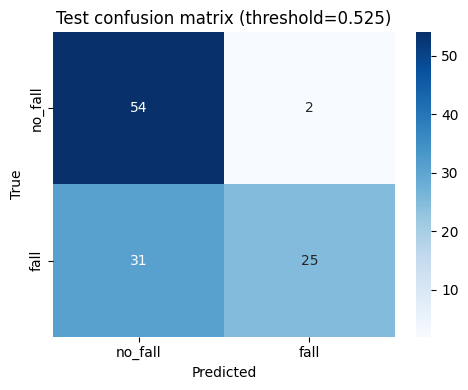

In [10]:
def find_best_threshold(y_true, prob):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        pred = (prob >= threshold).astype(int)
        macro_f1 = f1_score(y_true, pred, average='macro', zero_division=0)
        _, recall, _, _ = precision_recall_fscore_support(y_true, pred, labels=[0, 1], zero_division=0)
        rows.append((threshold, macro_f1, recall[1]))
    result = pd.DataFrame(rows, columns=['threshold', 'macro_f1', 'fall_recall'])
    # Nếu hòa F1, ưu tiên recall ngã cao hơn.
    best = result.sort_values(['macro_f1', 'fall_recall'], ascending=False).iloc[0]
    return float(best.threshold), result

val_prob = model.predict(X_val, verbose=0).ravel()
best_threshold, threshold_table = find_best_threshold(y_val, val_prob)
threshold_table.to_csv(WORK_DIR / 'validation_threshold_search.csv', index=False)
print(f'Best validation threshold: {best_threshold:.3f}')

test_prob = model.predict(X_test, verbose=0).ravel()
test_pred = (test_prob >= best_threshold).astype(int)
report = classification_report(y_test, test_pred, target_names=['no_fall', 'fall'], output_dict=True, zero_division=0)
print(classification_report(y_test, test_pred, target_names=['no_fall', 'fall'], zero_division=0))

metrics = {
    'threshold_selected_on_validation': best_threshold,
    'test_macro_f1': float(f1_score(y_test, test_pred, average='macro', zero_division=0)),
    'test_roc_auc': float(roc_auc_score(y_test, test_prob)) if len(np.unique(y_test)) == 2 else None,
    'test_pr_auc': float(average_precision_score(y_test, test_prob)) if len(np.unique(y_test)) == 2 else None,
    'classification_report': report,
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))
with open(WORK_DIR / 'test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

predictions = meta_test.copy()
predictions['true_label'] = y_test
predictions['fall_probability'] = test_prob
predictions['predicted_label'] = test_pred
predictions.to_csv(WORK_DIR / 'test_predictions.csv', index=False)

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no_fall', 'fall'], yticklabels=['no_fall', 'fall'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Test confusion matrix (threshold={best_threshold:.3f})')
plt.tight_layout(); plt.show()

## 10. Đường học và export

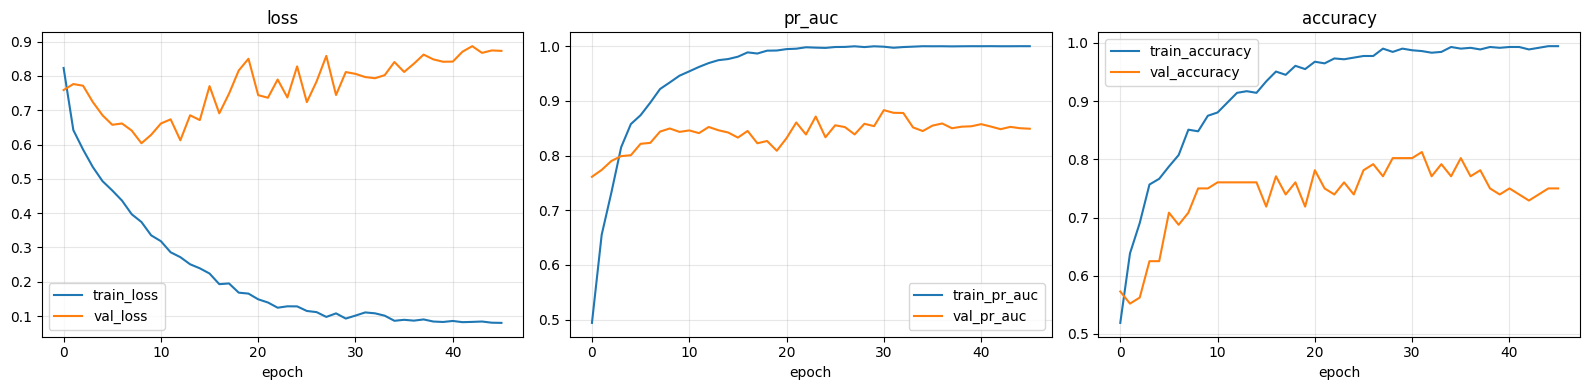

INFO:tensorflow:Assets written to: /tmp/tmpvoxkzo2w/assets


INFO:tensorflow:Assets written to: /tmp/tmpvoxkzo2w/assets


Saved artifact at '/tmp/tmpvoxkzo2w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 85), dtype=tf.float32, name='pose_sequence')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134845906680720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906680912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906681488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906680528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906681296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906681104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134844593301136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906678416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906678800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906678992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134845906676112: T

W0000 00:00:1784360182.065221      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784360182.065245      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784360182.091485      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [11]:
hist = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['loss', 'pr_auc', 'accuracy']):
    ax.plot(hist[metric], label=f'train_{metric}')
    ax.plot(hist[f'val_{metric}'], label=f'val_{metric}')
    ax.set_title(metric); ax.set_xlabel('epoch'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

with open(WORK_DIR / 'inference_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'max_frames': MAX_FRAMES,
        'num_features': int(X_train.shape[-1]),
        'keypoint_order': COCO_KEYPOINTS,
        'min_keypoint_confidence': MIN_KP_CONF,
        'threshold': best_threshold,
        'frame_index_base': FRAME_INDEX_BASE,
    }, f, indent=2, ensure_ascii=False)

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    (WORK_DIR / 'fall_detection_transformer.tflite').write_bytes(tflite_model)
    print('TFLite size:', len(tflite_model) / 1024, 'KB')
except Exception as exc:
    print('TFLite export không thành công; file .keras vẫn dùng được:', repr(exc))

print('Artifacts:', WORK_DIR)

In [12]:
from sklearn.metrics import fbeta_score

rows = []
for th in np.linspace(0.05, 0.95, 181):
    pred = (val_prob >= th).astype(int)
    f2 = fbeta_score(y_val, pred, beta=2, pos_label=1, zero_division=0)
    rec = ((pred == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    rows.append((th, f2, rec))

df_f2 = pd.DataFrame(rows, columns=['threshold', 'f2', 'fall_recall'])
best_f2 = df_f2.sort_values(['f2', 'fall_recall'], ascending=False).iloc[0]
print(f"Threshold F2: {best_f2.threshold:.3f} (F2={best_f2.f2:.3f}, recall={best_f2.fall_recall:.3f})")

# Đánh giá lại test với threshold mới
test_pred_f2 = (test_prob >= best_f2.threshold).astype(int)
print(classification_report(y_test, test_pred_f2, target_names=['no_fall', 'fall'], zero_division=0))


Threshold F2: 0.050 (F2=0.806, recall=0.833)
              precision    recall  f1-score   support

     no_fall       0.74      0.86      0.79        56
        fall       0.83      0.70      0.76        56

    accuracy                           0.78       112
   macro avg       0.78      0.78      0.78       112
weighted avg       0.78      0.78      0.78       112



## 11. Kiểm tra bắt buộc trước khi tin metric

- Train/val/test không dùng chung `chute`.
- Mỗi row nhãn tạo đúng một segment; không dùng toàn bộ video.
- Threshold chỉ lấy từ validation.
- Nếu test rất nhỏ, nên báo thêm kết quả 5-fold `StratifiedGroupKFold` theo chute thay vì kết luận từ một lần split.
- Kết quả giữa các camera của cùng chute không phải các mẫu độc lập hoàn toàn; vì vậy group split là điều kiện bắt buộc.
- Khi triển khai realtime, chạy cửa sổ trượt 60 frame và cần cơ chế debounce/cooldown để tránh phát nhiều cảnh báo cho cùng một cú ngã.